In [7]:
import numpy as np
import itertools
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import xarray as xr

In [8]:
def variance_partition(y, *predictors):
    """
    Compute variance partitioning for multiple predictors of a response variable.

    Parameters:
    y : array-like of shape (n_samples,)
        The response variable.
    *predictors : arbitrary number of array-like predictors of shape (n_samples,)

    Returns:
    dict
        A dictionary with keys representing combinations of predictors and values as R².
    """
    y = np.asarray(y).flatten()
    X_list = [np.asarray(x).reshape(-1, 1) for x in predictors]
    n = len(X_list)
    
    results = {}
    
    # Compute R² for all combinations of predictors
    for k in range(1, n + 1):
        for subset in itertools.combinations(range(n), k):
            X_combined = np.hstack([X_list[i] for i in subset])
            model = LinearRegression().fit(X_combined, y)
            r2 = r2_score(y, model.predict(X_combined))
            key = tuple(sorted(subset))
            results[key] = r2
    
    # Unique contributions
    unique = {}
    for i in range(n):
        others = tuple(j for j in range(n) if j != i)
        all_vars = tuple(sorted(list(others) + [i]))
        unique[i] = results.get(all_vars, 0) - results.get(others, 0)
    
    return {
        "full_model_r2": results.get(tuple(range(n)), None),
        "r2_by_combination": results,
        "unique_contributions": unique
    }

In [9]:
# Read detrended time series
ds = xr.open_dataset("data/detrended_driver_timeseries.nc")
time = ds['time'].values
flow = ds['flow'].values
airt = ds['airt'].values
radt = ds['radt'].values
gs_salt = ds['gs_salt'].values
gs_temp = ds['gs_temp'].values
gs_tran = ds['gs_tran'].values
wind_u = ds['wind_u'].values
wind_v = ds['wind_v'].values
ds.close()

ds = xr.open_dataset("data/detrended_estuary_timeseries.nc")
zeta = ds['zeta'].values
salt = ds['salt'].values
temp = ds['temp'].values
ds.close()

ds = xr.open_dataset("data/HR1_salt-temp_detrended.nc", decode_times=False)
hr1_time = ds['time'].values
hr1_salt = ds['salt'].values
hr1_temp = ds['temp'].values
ds.close()

indx = np.where(np.round(time,4) <= hr1_time[0])[0][-1]
NN = time[indx:].size

In [12]:
# Conduct Variance Partitioning on Detrended Time Series
print("Water Levels")
print(f"Steele Pt. {variance_partition(zeta[:,0], gs_tran, flow, wind_u, wind_v, radt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(zeta[:,1], gs_tran, flow, wind_u, wind_v, radt)['unique_contributions']}")
print("=====================")
print("Salinity - top")
print(f"Steele Pt. {variance_partition(salt[:,0,0], gs_salt, flow)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(salt[:,1,0], gs_salt, flow)['unique_contributions']}")
print(f"HR1 {variance_partition(salt[:,2,0], gs_salt, flow)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_salt[:NN,0], gs_salt[indx:], flow[indx:])['unique_contributions']}")
print("Salinity - bot")
print(f"Steele Pt. {variance_partition(salt[:,0,1], gs_salt, flow)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(salt[:,1,1], gs_salt, flow)['unique_contributions']}")
print(f"HR1 {variance_partition(salt[:,2,1], gs_salt, flow)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_salt[:NN,1], gs_salt[indx:], flow[indx:])['unique_contributions']}")
print("=====================")
print("Temperature - top")
print(f"Steele Pt. {variance_partition(temp[:,0,0], gs_temp, flow, airt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(temp[:,1,0], gs_temp, flow, airt)['unique_contributions']}")
print(f"HR1 {variance_partition(temp[:,2,0], gs_temp, flow, airt)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_temp[:NN,0], gs_temp[indx:], flow[indx:], airt[indx:])['unique_contributions']}")
print("Temperature - bot")
print(f"Steele Pt. {variance_partition(temp[:,0,1], gs_temp, flow, airt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(temp[:,1,1], gs_temp, flow, airt)['unique_contributions']}")
print(f"HR1 {variance_partition(temp[:,2,1], gs_temp, flow, airt)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_temp[:NN,1], gs_temp[indx:], flow[indx:], airt[indx:])['unique_contributions']}")

Water Levels
Steele Pt. {0: 0.16183340841542837, 1: 0.07258518434217465, 2: 0.02229644589625779, 3: 0.07253311835772491, 4: 0.024776263889356498}
Speedy Pt. {0: 0.15127175774366985, 1: 0.0855130287970759, 2: 0.03346674887169343, 3: 0.07182948025953884, 4: 0.023599248526598005}
Salinity - top
Steele Pt. {0: 0.002399714309017087, 1: 0.6325171697395613}
Speedy Pt. {0: 0.006025618395341548, 1: 0.48727029876439776}
HR1 {0: 0.001403171884406973, 1: 0.2494980927560183}
HR1 short {0: 0.05771763948286979, 1: 0.3254560073720322}
Salinity - bot
Steele Pt. {0: 8.236706451347775e-05, 1: 0.6776410339103369}
Speedy Pt. {0: 0.006106882273737013, 1: 0.5322659736100892}
HR1 {0: 4.4134162053843795e-06, 1: 0.3155317991000661}
HR1 short {0: 0.05432882881215795, 1: 0.3827219037444278}
Temperature - top
Steele Pt. {0: 0.008328311466810234, 1: 0.00021234329041042166, 2: 0.3062274859847235}
Speedy Pt. {0: 0.006673360101187575, 1: 0.0008730476237107654, 2: 0.3153217463483855}
HR1 {0: 0.0069603102103311665, 1: 0

In [14]:
# Conduct Variance Partitioning on Detrended Time Series
print("Water Levels")
print(f"Steele Pt. {variance_partition(zeta[:,0], gs_tran, flow, wind_u, wind_v, radt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(zeta[:,1], gs_tran, flow, wind_u, wind_v, radt)['unique_contributions']}")
print("=====================")
print("Salinity - top")
print(f"Steele Pt. {variance_partition(salt[:,0,0], gs_salt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(salt[:,1,0], gs_salt)['unique_contributions']}")
print(f"HR1 {variance_partition(salt[:,2,0], gs_salt)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_salt[:NN,0], gs_salt[indx:])['unique_contributions']}")
print("Salinity - bot")
print(f"Steele Pt. {variance_partition(salt[:,0,1], gs_salt)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(salt[:,1,1], gs_salt)['unique_contributions']}")
print(f"HR1 {variance_partition(salt[:,2,1], gs_salt)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_salt[:NN,1], gs_salt[indx:])['unique_contributions']}")
print("=====================")
print("Temperature - top")
print(f"Steele Pt. {variance_partition(temp[:,0,0], gs_temp, flow)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(temp[:,1,0], gs_temp, flow)['unique_contributions']}")
print(f"HR1 {variance_partition(temp[:,2,0], gs_temp, flow)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_temp[:NN,0], gs_temp[indx:], flow[indx:])['unique_contributions']}")
print("Temperature - bot")
print(f"Steele Pt. {variance_partition(temp[:,0,1], gs_temp, flow)['unique_contributions']}")
print(f"Speedy Pt. {variance_partition(temp[:,1,1], gs_temp, flow)['unique_contributions']}")
print(f"HR1 {variance_partition(temp[:,2,1], gs_temp, flow)['unique_contributions']}")
print(f"HR1 short {variance_partition(hr1_temp[:NN,1], gs_temp[indx:], flow[indx:])['unique_contributions']}")

Water Levels
Steele Pt. {0: 0.16183340841542837, 1: 0.07258518434217465, 2: 0.02229644589625779, 3: 0.07253311835772491, 4: 0.024776263889356498}
Speedy Pt. {0: 0.15127175774366985, 1: 0.0855130287970759, 2: 0.03346674887169343, 3: 0.07182948025953884, 4: 0.023599248526598005}
Salinity - top
Steele Pt. {0: 0.0756837436428377}
Speedy Pt. {0: 0.0769736874417346}
HR1 {0: 0.03230483776576354}
HR1 short {0: 0.1650428582513669}
Salinity - bot
Steele Pt. {0: 0.05832209934018773}
Speedy Pt. {0: 0.08229371125085361}
HR1 {0: 0.025773466005502788}
HR1 short {0: 0.1698163904687653}
Temperature - top
Steele Pt. {0: 0.5788484646507195, 1: 0.00015292163527425018}
Speedy Pt. {0: 0.5709249252291912, 1: 0.0007457884119000946}
HR1 {0: 0.5133972929040225, 1: 0.00590685667170654}
HR1 short {0: 0.5705565634259766, 1: 0.009104859907124396}
Temperature - bot
Steele Pt. {0: 0.6031123123116597, 1: 0.00026271174160374944}
Speedy Pt. {0: 0.576343931824882, 1: 0.0007473688117365374}
HR1 {0: 0.5485337391025813, 1: 

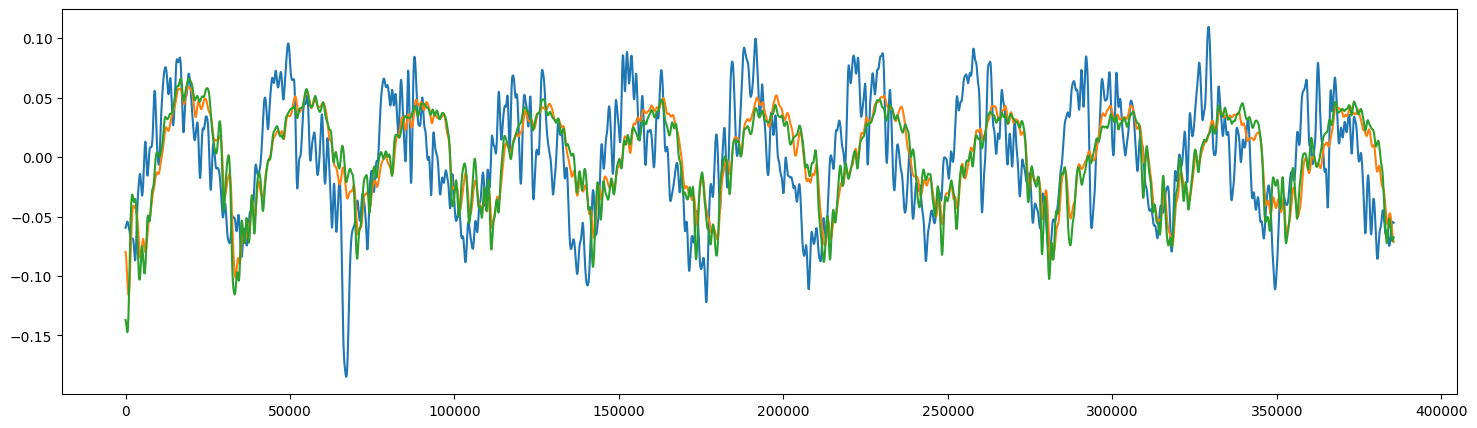

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=[18,5])
plt.plot(radt)
plt.plot(temp[:,0,1]/100)
plt.plot(airt/100)